In [2]:
!pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Self-healing variables
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Remove hardcoded num_classes - will be determined from dataset
print(f"Using device: {device}")
print("Switching to MobileNet V3 (Large) for faster CPU training...")
model = models.mobilenet_v3_large(weights='DEFAULT')

# Adjust the final layer - num_classes will be set after loading dataset
num_ftrs = model.classifier[3].in_features
# model.classifier[3] = nn.Linear(num_ftrs, num_classes)  # Will be set later

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

Using device: cpu
Switching to MobileNet V3 (Large) for faster CPU training...


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [6]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import os
import random
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import defaultdict

# Use local path
dataset_root = "./PlantVillage" 

normalize = transforms.Normalize([0.5]*3, [0.5]*3)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    normalize
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

# Loading full dataset metadata to filter
temp_dataset = datasets.ImageFolder(dataset_root)
class_to_indices = defaultdict(list)

# Group indices by class
for idx, (_, class_id) in enumerate(temp_dataset.samples):
    class_to_indices[class_id].append(idx)

# Use all images, no subset selection
subset_indices = []
for class_id, indices in class_to_indices.items():
    subset_indices.extend(indices)

random.shuffle(subset_indices)
class_names = temp_dataset.classes
num_classes = len(class_names)

train_subset_idx, val_subset_idx = train_test_split(
    subset_indices,
    test_size=0.2,
    stratify=[temp_dataset.targets[i] for i in subset_indices],
    random_state=42
)

train_dataset = Subset(datasets.ImageFolder(dataset_root, transform=train_transform), train_subset_idx)
val_dataset = Subset(datasets.ImageFolder(dataset_root, transform=val_transform), val_subset_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Using full dataset: {len(subset_indices)} total samples.")
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")
print("Classes:", num_classes)

Subset selection complete: Max 500 per class.
Training samples: 6020, Validation samples: 1505
Classes: 16


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Self-healing variables
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Get num_classes dynamically from dataset if not already set
if 'num_classes' not in locals() or num_classes == 15:  # 15 was the old hardcoded value
    try:
        temp_dataset = datasets.ImageFolder("./PlantVillage")
        num_classes = len(temp_dataset.classes)
        print(f"Detected {num_classes} classes from dataset")
    except:
        num_classes = 38  # Default to full PlantVillage dataset
        print(f"Could not load dataset, defaulting to {num_classes} classes")

print(f"Using device: {device}")
print("Switching to MobileNet V3 (Large) for faster CPU training...")
model = models.mobilenet_v3_large(weights='DEFAULT')

# Adjust the final layer
num_ftrs = model.classifier[3].in_features
model.classifier[3] = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

Using device: cpu
Switching to MobileNet V3 (Large) for faster CPU training...


In [9]:
epochs = 5 # Reducing epochs to 5 for speed, 500 images per class is enough

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # Universal handling for CPU/GPU
        if torch.cuda.is_available():
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = total_loss / len(train_loader)

    # ---- Validation ----
    model.eval()
    val_correct, val_total, val_loss_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item()
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total
    val_loss = val_loss_total / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


Epoch 1/5 | Train Acc: 79.90% | Val Acc: 67.97%
Epoch 2/5 | Train Acc: 88.06% | Val Acc: 80.07%
Epoch 3/5 | Train Acc: 89.52% | Val Acc: 82.66%
Epoch 4/5 | Train Acc: 90.03% | Val Acc: 87.38%
Epoch 5/5 | Train Acc: 90.56% | Val Acc: 86.84%


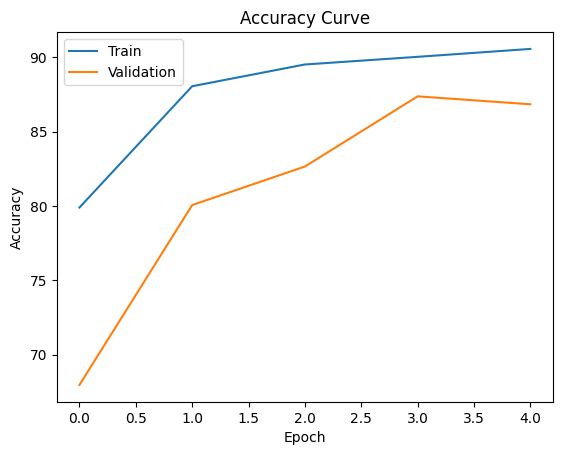

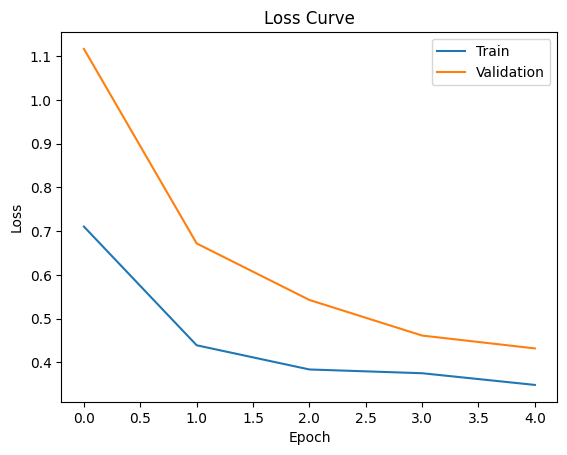

In [10]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [11]:
from sklearn.metrics import classification_report
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        # Removing .logits for MobileNet
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.96      1.00      0.98       100
                     Pepper__bell___healthy       0.94      1.00      0.97       100
                               PlantVillage       0.09      0.06      0.07       100
                      Potato___Early_blight       0.88      1.00      0.94       100
                       Potato___Late_blight       0.97      0.87      0.92       100
                           Potato___healthy       0.97      1.00      0.98        30
                      Tomato_Bacterial_spot       0.87      0.60      0.71       100
                        Tomato_Early_blight       0.90      0.95      0.92       100
                         Tomato_Late_blight       0.81      0.91      0.85       100
                           Tomato_Leaf_Mold       0.96      0.91      0.93       100
                  Tomato_Septoria_leaf_spot       0.80      0.98

In [12]:
import random
from PIL import Image

# Pick a random image from the dataset
all_samples = datasets.ImageFolder(dataset_root).samples
sample_path, sample_label = random.choice(all_samples)
print("Actual:", class_names[sample_label])

image = Image.open(sample_path).convert("RGB")
input_tensor = val_transform(image).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    # Removing .logits because standard PyTorch models return tensors directly
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)

top_prob, top_class = torch.max(probs, 1)

print("Predicted:", class_names[top_class.item()])
print("Confidence: {:.2f}%".format(top_prob.item()*100))


Actual: PlantVillage
Predicted: Pepper__bell___Bacterial_spot
Confidence: 98.26%


In [13]:
print(f"Train Acc: {train_acc:.2f}%")
print(f"Val Acc: {val_acc:.2f}%")

Train Acc: 90.56%
Val Acc: 86.84%


In [14]:
# Save the trained model
torch.save(model.state_dict(), 'crop_disease_model.pth')
print("Model saved as 'crop_disease_model.pth'")

Model saved as 'crop_disease_model.pth'


In [15]:
model = models.mobilenet_v3_large(weights=None)

num_ftrs = model.classifier[3].in_features
model.classifier[3] = nn.Linear(num_ftrs, num_classes)

model.load_state_dict(torch.load('crop_disease_model.pth', map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully ✅")

Model loaded successfully ✅


In [40]:
from PIL import Image

image_path = r"PlantVillage\Pepper__bell___Bacterial_spot\0b47ce18-7cfe-45e8-b21e-b83cb6282455___JR_B.Spot 3162.JPG"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)

top_prob, top_class = torch.max(probs, 1)

print("Predicted Disease:", class_names[top_class.item()])
print("Confidence:", top_prob.item()*100)


Predicted Disease: Pepper__bell___Bacterial_spot
Confidence: 98.13433289527893


In [41]:
from PIL import Image

image_path = r"D:\crop disease project\PlantVillage\Tomato__Tomato_mosaic_virus\0b5e2269-7b37-43ac-9a96-c62b9bba2383___PSU_CG 2243.JPG"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)

top_prob, top_class = torch.max(probs, 1)

print("Predicted Disease:", class_names[top_class.item()])
print("Confidence:", top_prob.item()*100)


Predicted Disease: Tomato__Tomato_mosaic_virus
Confidence: 98.51535558700562


In [43]:
from PIL import Image

image_path = r"D:\crop disease project\PlantVillage\Tomato_Early_blight\0a2726e0-3358-4a46-b6dc-563a5a9f2bdf___RS_Erly.B 7860.JPG"
image = Image.open(image_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)

top_prob, top_class = torch.max(probs, 1)

print("Predicted Disease:", class_names[top_class.item()])
print("Confidence:", top_prob.item()*100)

Predicted Disease: Tomato_Early_blight
Confidence: 47.60883450508118
